## Level 3: Core Numerical Methods Engine
    
**Course:** ICS 2207 Scientific Computing 

**Project:** HydroSense-Kenya  

**Main Goal:** Implement core numerical methods from scratch and apply them to irrigation decisions. 

**Topic:** Root Finding, Differentiation, Integration, Linear Systems

**Prepared For:** Dr. Lawrence Nderu


## Purpose of this Notebook

This notebook implements and compares numerical methods for irrigation decision support:

- **Root finding** to calculate required irrigation amount
- **Numerical differentiation** to estimate soil moisture change rates
- **Numerical integration** to compute cumulative water deficit
- **Linear systems** to solve three-zone water allocation

All methods are implemented and compared for accuracy and convergence.

## 1. Import Libraries and Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add project root to path
sys.path.append(os.path.dirname(os.getcwd()))

from src.numerical_methods import (
    bisection, newton_raphson, secant,
    irrigation_root_function,
    forward_difference, backward_difference, central_difference,
    soil_moisture_rate,
    trapezoidal_rule, simpsons_13_rule, cumulative_water_deficit,
    gaussian_elimination, lu_decomposition, three_zone_water_allocation
)

%matplotlib inline

Testing ET function:
ET at 25°C, 2m/s wind, 0.7 solar, 60% humidity: 3.88 mm

Testing Water Balance function:
Starting at 30%, after rain + ET - drainage: 31.50%


## 2. Load Cleaned Dataset

In [2]:
project_root = os.path.dirname(os.getcwd())
processed_path = os.path.join(project_root, "data", "processed", "cleaned_irrigation_dataset.csv")

df = pd.read_csv(processed_path)

# Extract weather and soil data
weather_data = df[df['dataset_source'] == 'weather'].copy()
soil_data = df[df['dataset_source'] == 'soil'].copy()

print(f"Weather records: {len(weather_data)}")
print(f"Soil records: {len(soil_data)}")

Weather records: 27
Soil records: 89


## 3. Root Finding for Irrigation Amount

Problem: Find irrigation amount I such that:

`S_current + rain + I - ET - drainage*S_current = target_moisture`

In [3]:
# Define parameters
current_moisture = 22.0
target_moisture = 35.0
daily_et = 4.5
daily_rain = 0.0
drainage_coef = 0.15

# Create function f(I) = 0
f_irrigation = irrigation_root_function(
    soil_moisture=current_moisture,
    target=target_moisture,
    et=daily_et,
    rain=daily_rain,
    drainage=drainage_coef
)

# Derivative for Newton-Raphson
def df_irrigation(I):
    return 1.0

print("=" * 60)
print("ROOT FINDING: Irrigation Amount Needed")
print("=" * 60)
print(f"Current soil moisture: {current_moisture}%")
print(f"Target soil moisture: {target_moisture}%")
print(f"Daily ET: {daily_et} mm")
print(f"Daily rain: {daily_rain} mm")
print(f"Drainage coefficient: {drainage_coef}")

ROOT FINDING: Irrigation Amount Needed
Current soil moisture: 22.0%
Target soil moisture: 35.0%
Daily ET: 4.5 mm
Daily rain: 0.0 mm
Drainage coefficient: 0.15


## 4. Comparint the Root Finding Methods

ROOT FINDING METHOD COMPARISON
        Method  Irrigation Needed (mm)  Iterations  Final Error
     Bisection                    20.8          26 3.159046e-07
Newton-Raphson                    20.8           1 0.000000e+00
        Secant                    20.8           2 0.000000e+00

Verification: Applying 20.80 mm of water
brings soil moisture from 22.0% to target.


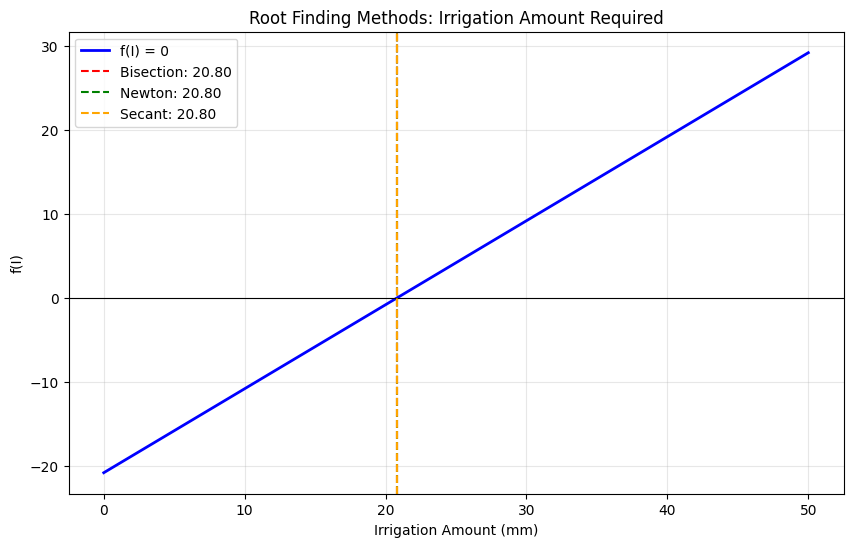

In [4]:
# Apply all three methods
bisection_root, bisection_iter, bisection_error = bisection(f_irrigation, 0, 50, tol=1e-6)
newton_root, newton_iter, newton_error = newton_raphson(f_irrigation, df_irrigation, x0=25, tol=1e-6)
secant_root, secant_iter, secant_error = secant(f_irrigation, x0=0, x1=30, tol=1e-6)

# Create comparison table
comparison_data = {
    'Method': ['Bisection', 'Newton-Raphson', 'Secant'],
    'Irrigation Needed (mm)': [bisection_root, newton_root, secant_root],
    'Iterations': [bisection_iter, newton_iter, secant_iter],
    'Final Error': [bisection_error, newton_error, secant_error]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 60)
print("ROOT FINDING METHOD COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))
print()
print(f"Verification: Applying {comparison_df['Irrigation Needed (mm)'][0]:.2f} mm of water")
print(f"brings soil moisture from {current_moisture}% to target.")

# Visualize convergence
I_range = np.linspace(0, 50, 200)
f_values = [f_irrigation(I) for I in I_range]

plt.figure(figsize=(10, 6))
plt.plot(I_range, f_values, 'b-', linewidth=2, label='f(I) = 0')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=bisection_root, color='red', linestyle='--', label=f'Bisection: {bisection_root:.2f}')
plt.axvline(x=newton_root, color='green', linestyle='--', label=f'Newton: {newton_root:.2f}')
plt.axvline(x=secant_root, color='orange', linestyle='--', label=f'Secant: {secant_root:.2f}')
plt.xlabel('Irrigation Amount (mm)')
plt.ylabel('f(I)')
plt.title('Root Finding Methods: Irrigation Amount Required')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Numerical Differentiation - Soil Moisture Rate of Change

Estimate dS/dt using forward, backward, and central differences.

NUMERICAL DIFFERENTIATION: Soil Moisture Rate of Change

Soil moisture readings (Zone A, first 10 days):
  Day 0: 33.2%
  Day 1: 36.1%
  Day 2: 33.7%
  Day 3: 31.8%
  Day 4: 33.3%
  Day 5: 34.1%
  Day 6: 30.6%
  Day 7: 31.4%
  Day 8: 29.1%
  Day 9: 29.7%

Rate of change (% per day):
Day    Forward      Backward     Central     
---------------------------------------------
1      -2.4000      2.9000       0.2500      
2      -1.9000      -2.4000      -2.1500     
3      1.5000       -1.9000      -0.2000     
4      0.8000       1.5000       1.1500      
5      -3.5000      0.8000       -1.3500     
6      0.8000       -3.5000      -1.3500     
7      -2.3000      0.8000       -0.7500     
8      0.6000       -2.3000      -0.8500     


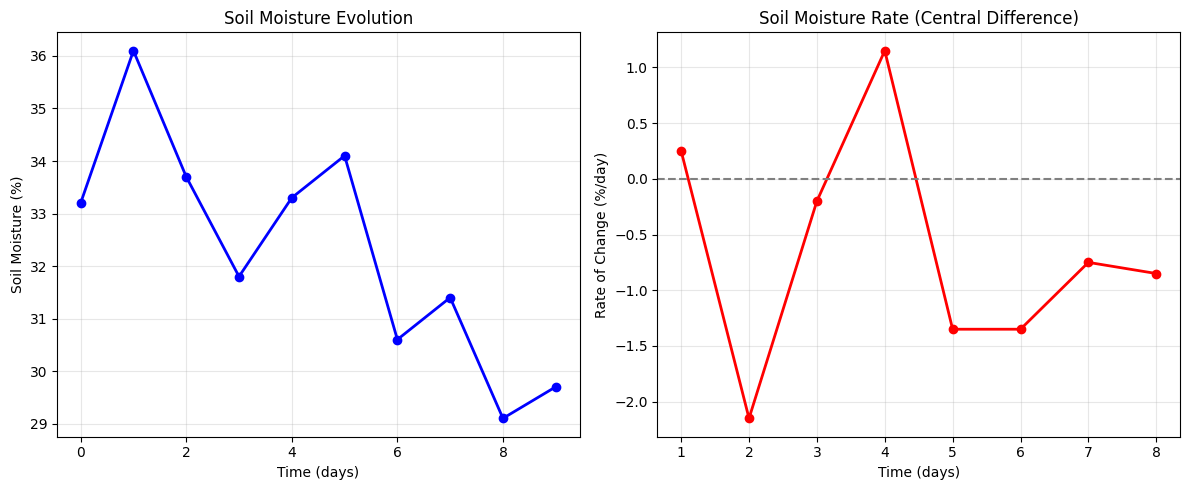

In [6]:
# Extract soil moisture over time from Zone A
zone_a_data = soil_data[soil_data['zone_id'] == 'Zone_A'].copy()
zone_a_data = zone_a_data.sort_values('timestamp')
zone_a_data['days'] = range(len(zone_a_data))

moisture_values = zone_a_data['soil_moisture_pct'].dropna().values[:10]
time_days = np.arange(len(moisture_values))

print("=" * 60)
print("NUMERICAL DIFFERENTIATION: Soil Moisture Rate of Change")
print("=" * 60)
print(f"\nSoil moisture readings (Zone A, first 10 days):")
for i, m in enumerate(moisture_values):
    print(f"  Day {i}: {m:.1f}%")

# Calculate rates
rates = soil_moisture_rate(moisture_values, time_days)

print("\nRate of change (% per day):")
print(f"{'Day':<6} {'Forward':<12} {'Backward':<12} {'Central':<12}")
print("-" * 45)

for i in range(1, len(moisture_values) - 1):
    forward = rates['forward'][i] if i < len(rates['forward']) else None
    backward = rates['backward'][i-1] if i-1 < len(rates['backward']) else None
    central = rates['central'][i-1] if i-1 < len(rates['central']) else None
    
    print(f"{i:<6} {forward:<12.4f} {backward:<12.4f} {central:<12.4f}")

    # Visualize differentiation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time_days, moisture_values, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Time (days)')
plt.ylabel('Soil Moisture (%)')
plt.title('Soil Moisture Evolution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
central_days = time_days[1:-1]
plt.plot(central_days, rates['central'], 'ro-', linewidth=2, markersize=6)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Rate of Change (%/day)')
plt.title('Soil Moisture Rate (Central Difference)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Numerical Integration - Cumulative Water Deficit

Estimate total water deficit using Trapezoidal and Simpson's rules.

NUMERICAL INTEGRATION: Cumulative Water Deficit
Time range: 0.0 to 30.0 days
Number of points: 31

Method               Cumulative Deficit (mm)  
---------------------------------------------
Trapezoidal Rule     96.75                    
Simpson's 1/3 Rule   96.83                    
NumPy trapezoid      96.75                    

INTEGRATION COMPARISON TABLE
       Method  Integral Value (mm)  Difference from NumPy
  Trapezoidal            96.750000           1.421085e-14
Simpson's 1/3            96.833333           8.333333e-02


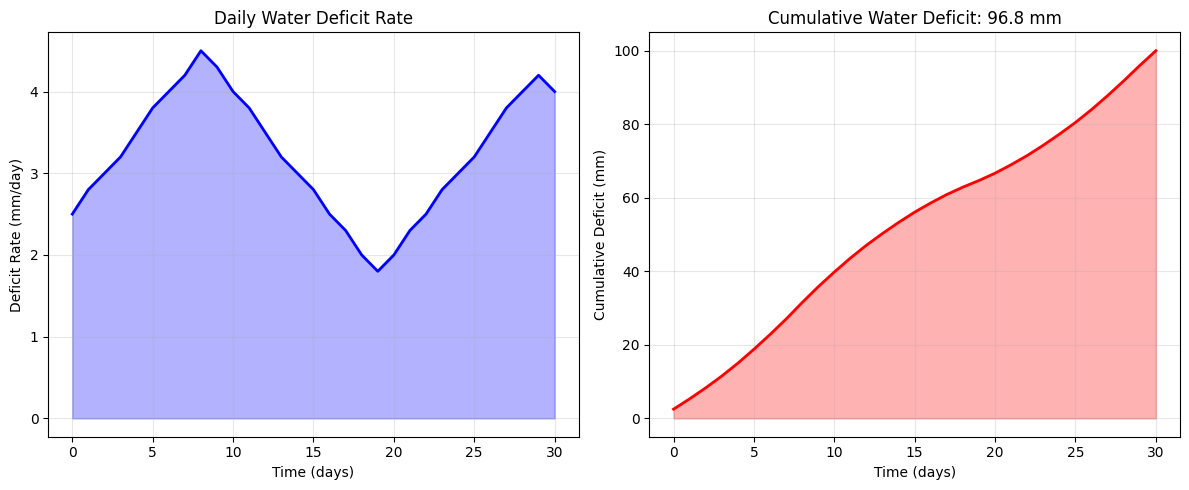

In [8]:
# Create sample deficit data
time_days = np.linspace(0, 30, 31)
deficit_rate = np.array([
    2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 4.2, 4.5, 4.3,
    4.0, 3.8, 3.5, 3.2, 3.0, 2.8, 2.5, 2.3, 2.0, 1.8,
    2.0, 2.3, 2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 4.2, 4.0
])

print("=" * 60)
print("NUMERICAL INTEGRATION: Cumulative Water Deficit")
print("=" * 60)
print(f"Time range: {time_days[0]} to {time_days[-1]} days")
print(f"Number of points: {len(time_days)}")

# Apply integration methods
trap_integral = trapezoidal_rule(deficit_rate, time_days)
simp_integral = simpsons_13_rule(deficit_rate, time_days)

# Verification
np_trap = np.trapezoid(deficit_rate, time_days)

print(f"\n{'Method':<20} {'Cumulative Deficit (mm)':<25}")
print("-" * 45)
print(f"{'Trapezoidal Rule':<20} {trap_integral:<25.2f}")
print(f"{'Simpson\'s 1/3 Rule':<20} {simp_integral:<25.2f}")
print(f"{'NumPy trapezoid':<20} {np_trap:<25.2f}")

# Comparison table
integration_comparison = pd.DataFrame({
    'Method': ['Trapezoidal', "Simpson's 1/3"],
    'Integral Value (mm)': [trap_integral, simp_integral],
    'Difference from NumPy': [abs(trap_integral - np_trap), abs(simp_integral - np_trap)]
})

print("\n" + "=" * 60)
print("INTEGRATION COMPARISON TABLE")
print("=" * 60)
print(integration_comparison.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time_days, deficit_rate, 'b-', linewidth=2)
plt.fill_between(time_days, deficit_rate, alpha=0.3, color='blue')
plt.xlabel('Time (days)')
plt.ylabel('Deficit Rate (mm/day)')
plt.title('Daily Water Deficit Rate')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumulative = np.cumsum(deficit_rate) * (time_days[1] - time_days[0])
plt.plot(time_days, cumulative, 'r-', linewidth=2)
plt.fill_between(time_days, cumulative, alpha=0.3, color='red')
plt.xlabel('Time (days)')
plt.ylabel('Cumulative Deficit (mm)')
plt.title(f'Cumulative Water Deficit: {trap_integral:.1f} mm')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Linear Systems - Three-Zone Water Allocation

Solve Ax = b for tomato, kale, and maize zones.

In [9]:
print("=" * 60)
print("THREE-ZONE WATER ALLOCATION PROBLEM")
print("=" * 60)

demands = {
    'Zone_A (Tomato)': 4.5,
    'Zone_B (Kale)': 3.8,
    'Zone_C (Maize)': 4.0
}
total_water = 12.0

print("\nCrop Water Demands:")
for zone, demand in demands.items():
    print(f"  {zone}: {demand} mm/day")
print(f"\nTotal available water: {total_water} mm/day")

allocation, method = three_zone_water_allocation(
    demands=[demands['Zone_A (Tomato)'], demands['Zone_B (Kale)'], demands['Zone_C (Maize)']],
    total_water=total_water
)

print(f"\n{'='*60}")
print("SOLUTION: Optimal Water Allocation")
print(f"{'='*60}")
print(f"{'Zone':<20} {'Allocated (mm/day)':<20} {'Demand Met (%)':<15}")
print("-" * 55)

zones = ['Zone_A (Tomato)', 'Zone_B (Kale)', 'Zone_C (Maize)']
for i, zone in enumerate(zones):
    demand = demands[zone]
    pct_met = (allocation[i] / demand) * 100 if demand > 0 else 0
    print(f"{zone:<20} {allocation[i]:<20.2f} {pct_met:<15.1f}")

print("-" * 55)
print(f"{'Total Allocated':<20} {sum(allocation):<20.2f}")
print(f"{'Method used':<20} {method:<20}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
if sum(allocation) <= total_water:
    print("✓ Allocation is feasible within available water budget")
if all(a >= 0 for a in allocation):
    print("✓ All allocations are non-negative")

print("\nRecommendation:")
if allocation[0] < demands['Zone_A (Tomato)']:
    print("  - Tomato zone is under-irrigated - prioritize")
if allocation[2] < demands['Zone_C (Maize)']:
    print("  - Maize zone requires supplemental irrigation")

THREE-ZONE WATER ALLOCATION PROBLEM

Crop Water Demands:
  Zone_A (Tomato): 4.5 mm/day
  Zone_B (Kale): 3.8 mm/day
  Zone_C (Maize): 4.0 mm/day

Total available water: 12.0 mm/day

SOLUTION: Optimal Water Allocation
Zone                 Allocated (mm/day)   Demand Met (%) 
-------------------------------------------------------
Zone_A (Tomato)      4.50                 100.0          
Zone_B (Kale)        3.80                 100.0          
Zone_C (Maize)       3.70                 92.5           
-------------------------------------------------------
Total Allocated      12.00               
Method used          gaussian            

INTERPRETATION
✓ Allocation is feasible within available water budget
✓ All allocations are non-negative

Recommendation:
  - Maize zone requires supplemental irrigation


## 8. Summary of All Level 3 Methods

This table summarizes the numerical methods implemented and their performance.

In [11]:
summary_data = {
    'Method Category': ['Root Finding', 'Root Finding', 'Root Finding',
                        'Differentiation', 'Integration', 'Integration',
                        'Linear Systems'],
    'Method Name': ['Bisection', 'Newton-Raphson', 'Secant',
                    'Central Difference', 'Trapezoidal', "Simpson's 1/3",
                    'Gaussian Elimination'],
    'Convergence Rate': ['Linear O(h)', 'Quadratic O(h²)', 'Superlinear',
                         'O(h²)', 'O(h²)', 'O(h⁴)', 'O(n³)'],
    'Key Feature': ['Guaranteed if bracketed', 'Requires derivative', 'No derivative needed',
                    'Most accurate', 'Simple and robust', 'More accurate', 'Direct solution']
}

summary_df = pd.DataFrame(summary_data)

print("=" * 70)
print("LEVEL 3 NUMERICAL METHODS - COMPLETE SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

LEVEL 3 NUMERICAL METHODS - COMPLETE SUMMARY
Method Category          Method Name Convergence Rate             Key Feature
   Root Finding            Bisection      Linear O(h) Guaranteed if bracketed
   Root Finding       Newton-Raphson  Quadratic O(h²)     Requires derivative
   Root Finding               Secant      Superlinear    No derivative needed
Differentiation   Central Difference            O(h²)           Most accurate
    Integration          Trapezoidal            O(h²)       Simple and robust
    Integration        Simpson's 1/3            O(h⁴)           More accurate
 Linear Systems Gaussian Elimination            O(n³)         Direct solution
